<a href="https://colab.research.google.com/github/aryan22796/AI_learning_basic/blob/main/LLM_Basics_Day1_Learning_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 1 — LLM Basics: Internals, Tokens, Temperature, Context Window, Embeddings & Similarity



1. What an LLM is internally doing
2. Tokens and tokenization
3. Context and context window
4. Temperature and sampling
5. Embeddings as vectors
6. Embedding geometry
7. Dot product, cosine similarity, and semantic search intuition


## 0. Setup

We will use only basic Python libraries so students can run this locally without paid APIs.

This notebook does **not** require OpenAI, Hugging Face, or internet access.

In [1]:
import math
import random
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
random.seed(42)

# 1. What is an LLM?

An **LLM** is a model trained on a large amount of text to predict language patterns.

At inference time, a simplified view is:

```text
Input text → Tokenization → Token IDs → Neural network → Next-token probabilities → Sampling/decoding → Output text
```

Important point for students:

> An LLM does not directly understand words like humans. It converts text into numbers, processes those numbers, and predicts the next likely token.

Example:

```text
Input:  The capital of India is
Next-token prediction: Delhi, New, Mumbai, ...
```

The model gives a probability distribution over possible next tokens.

## 1.1 LLM internal pipeline

Think of an LLM as a **next-token prediction engine**.

```text
User Prompt
   ↓
Tokenizer
   ↓
Token IDs
   ↓
Embedding Layer
   ↓
Transformer Blocks
   ↓
Logits
   ↓
Softmax Probabilities
   ↓
Sampling / Decoding
   ↓
Generated Answer
```

### Important internal terms

| Term | Simple meaning |
|---|---|
| Tokenizer | Splits text into small pieces called tokens |
| Token ID | Numeric ID for each token |
| Embedding | Vector representation of a token/text |
| Transformer | Neural network architecture used in most modern LLMs |
| Logits | Raw scores before probability conversion |
| Softmax | Converts raw scores into probabilities |
| Decoding | Choosing the next token from probabilities |

# 2. Tokens

A **token** is a small unit of text.

A token can be:

- A word: `hello`
- Part of a word: `un`, `believ`, `able`
- A punctuation mark: `.`
- A space pattern
- A number chunk

LLMs do not read text as full sentences directly. They read a sequence of tokens.

Example:

```text
"I love data engineering!"
```

may become something like:

```text
["I", " love", " data", " engineering", "!"]
```

Actual tokenization depends on the tokenizer.

## 2.1 Simple tokenizer demo

This is **not** a production tokenizer. It is a simple teaching tokenizer.

It splits text into words and punctuation so students can understand the idea.

In [2]:
def simple_tokenize(text):
    # Simple teaching tokenizer: split words, numbers, and punctuation.
    return re.findall(r"\w+|[^\w\s]", text, re.UNICODE)

examples = [
    "I love data engineering!",
    "LLMs predict the next token.",
    "Nagendra is learning GenAI in 2026.",
    "Tokenization is not always equal to word splitting."
]

for text in examples:
    tokens = simple_tokenize(text)
    print("Text:", text)
    print("Tokens:", tokens)
    print("Token count:", len(tokens))
    print("-" * 70)

Text: I love data engineering!
Tokens: ['I', 'love', 'data', 'engineering', '!']
Token count: 5
----------------------------------------------------------------------
Text: LLMs predict the next token.
Tokens: ['LLMs', 'predict', 'the', 'next', 'token', '.']
Token count: 6
----------------------------------------------------------------------
Text: Nagendra is learning GenAI in 2026.
Tokens: ['Nagendra', 'is', 'learning', 'GenAI', 'in', '2026', '.']
Token count: 7
----------------------------------------------------------------------
Text: Tokenization is not always equal to word splitting.
Tokens: ['Tokenization', 'is', 'not', 'always', 'equal', 'to', 'word', 'splitting', '.']
Token count: 9
----------------------------------------------------------------------


## 2.2 Token IDs

After tokenization, each token is mapped to a numeric ID.

Example:

```text
"I"       → 101
"love"    → 538
"data"    → 924
"!"       → 12
```

The model works with token IDs, not raw text.

In [3]:
training_text = (
    "I love data engineering. I love machine learning. "
    "LLMs predict the next token. Data engineering uses pipelines."
)

tokens = simple_tokenize(training_text.lower())
vocab = sorted(set(tokens))
token_to_id = {token: idx for idx, token in enumerate(vocab)}
id_to_token = {idx: token for token, idx in token_to_id.items()}

print("Vocabulary size:", len(vocab))
print("Vocabulary:", vocab)

sample = "I love data"
sample_tokens = simple_tokenize(sample.lower())
sample_ids = [token_to_id[token] for token in sample_tokens]

print("\nSample text:", sample)
print("Tokens:", sample_tokens)
print("Token IDs:", sample_ids)

Vocabulary size: 14
Vocabulary: ['.', 'data', 'engineering', 'i', 'learning', 'llms', 'love', 'machine', 'next', 'pipelines', 'predict', 'the', 'token', 'uses']

Sample text: I love data
Tokens: ['i', 'love', 'data']
Token IDs: [3, 6, 1]


## Teaching note: Why token count matters

Token count matters because:

1. LLM cost is often based on tokens.
2. Context window is measured in tokens.
3. Longer input means more computation.
4. If the prompt is too long, older content may be truncated.

Simple approximation often used in English:

```text
1 token ≈ 3 to 4 characters
1 token ≈ 0.75 words
```

This is only an approximation. Real token count depends on the tokenizer and language.

# 3. Context and Context Window

**Context** is the information the model can see while generating an answer.

This includes:

- System instructions
- User prompt
- Previous conversation messages
- Retrieved documents
- Tool outputs
- Any examples included in the prompt

The **context window** is the maximum number of tokens the model can consider at one time.

Example:

```text
Model context window = 8,000 tokens
Input prompt = 7,500 tokens
Model answer can use only remaining space for output
```

If the conversation becomes too long, some earlier information may no longer fit.

## 3.1 Context window simulation

Let us simulate a tiny model with context window = 12 tokens.

If we pass more than 12 tokens, only the latest 12 tokens remain visible.

In [4]:
def apply_context_window(tokens, window_size):
    # Keep only the last `window_size` tokens.
    return tokens[-window_size:]

long_prompt = (
    "Student name is Rahul. Rahul likes Python. Rahul is learning machine learning. "
    "Today we are teaching tokens, context window, embeddings, and similarity."
)

tokens = simple_tokenize(long_prompt)
window_size = 12
visible_tokens = apply_context_window(tokens, window_size)

print("Total tokens:", len(tokens))
print("Context window size:", window_size)
print("\nAll tokens:")
print(tokens)
print("\nVisible tokens inside context window:")
print(visible_tokens)

Total tokens: 29
Context window size: 12

All tokens:
['Student', 'name', 'is', 'Rahul', '.', 'Rahul', 'likes', 'Python', '.', 'Rahul', 'is', 'learning', 'machine', 'learning', '.', 'Today', 'we', 'are', 'teaching', 'tokens', ',', 'context', 'window', ',', 'embeddings', ',', 'and', 'similarity', '.']

Visible tokens inside context window:
['are', 'teaching', 'tokens', ',', 'context', 'window', ',', 'embeddings', ',', 'and', 'similarity', '.']



If important information is outside the context window, the model cannot directly use it.

Example:

```text
Earlier: Student name is Rahul.
Later: What is the student name?
```

If `Student name is Rahul` is no longer inside the context window, the model may not answer correctly unless it has memory or retrieval.

This is why Retrieval-Augmented Generation (RAG) is useful: it brings relevant information back into the context.

# 4. Next-token prediction

An LLM generates text one token at a time.

Example:

```text
Prompt: The capital of India is
Model predicts next token probabilities:
Delhi: 0.70
New:   0.20
Mumbai:0.05
Paris: 0.01
Other: 0.04
```

The model then chooses one token, appends it to the prompt, and repeats the process.

In [5]:
next_token_probs = {
    "Delhi": 0.70,
    "New": 0.20,
    "Mumbai": 0.05,
    "Paris": 0.01,
    "Other": 0.04,
}

pd.DataFrame(next_token_probs.items(), columns=["token", "probability"])

,token,probability
0,Delhi,0.70
1,New,0.20
2,Mumbai,0.05
3,Paris,0.01
4,Other,0.04


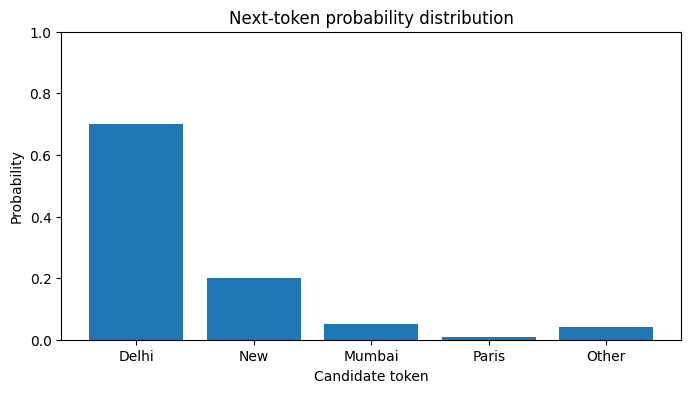

In [6]:
plt.figure(figsize=(8, 4))
plt.bar(next_token_probs.keys(), next_token_probs.values())
plt.title("Next-token probability distribution")
plt.xlabel("Candidate token")
plt.ylabel("Probability")
plt.ylim(0, 1)
plt.show()

# 5. Temperature

**Temperature** controls randomness during token selection.

- Low temperature → safer, more deterministic, less creative
- High temperature → more random, more creative, more risk of mistakes

Temperature does not change what the model knows. It changes how strongly we sample from the probability distribution.

Common teaching interpretation:

| Temperature | Behavior |
|---:|---|
| 0 | Almost deterministic / greedy |
| 0.2 | Very focused |
| 0.7 | Balanced |
| 1.0 | More diverse |
| >1.0 | More random |

## 5.1 Softmax and temperature

The model produces raw scores called **logits**.

Softmax converts logits into probabilities.

Temperature modifies logits before softmax:

```text
softmax(logits / temperature)
```

When temperature is low, the biggest score becomes much more dominant.

When temperature is high, probabilities become more spread out.

In [7]:
def softmax(logits, temperature=1.0):
    logits = np.array(logits, dtype=float)
    scaled = logits / temperature
    scaled = scaled - np.max(scaled)  # numerical stability
    exp_values = np.exp(scaled)
    return exp_values / exp_values.sum()

candidate_tokens = ["Delhi", "New", "Mumbai", "Paris", "Other"]
logits = np.array([5.0, 3.8, 2.4, 0.7, 1.2])

temps = [0.2, 0.7, 1.0, 1.5]
rows = []
for temp in temps:
    probs = softmax(logits, temperature=temp)
    for token, prob in zip(candidate_tokens, probs):
        rows.append({"temperature": temp, "token": token, "probability": prob})

prob_df = pd.DataFrame(rows)
prob_df.pivot(index="token", columns="temperature", values="probability").round(3)

temperature,0.2,0.7,1.0,1.5
token,,,,
Delhi,0.998,0.826,0.709,0.567
Mumbai,0.000,0.020,0.053,0.100
New,0.002,0.149,0.213,0.255
Other,0.000,0.004,0.016,0.045
Paris,0.000,0.002,0.010,0.032


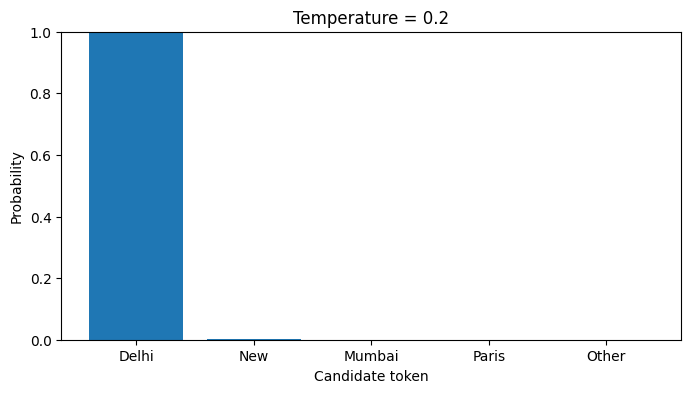

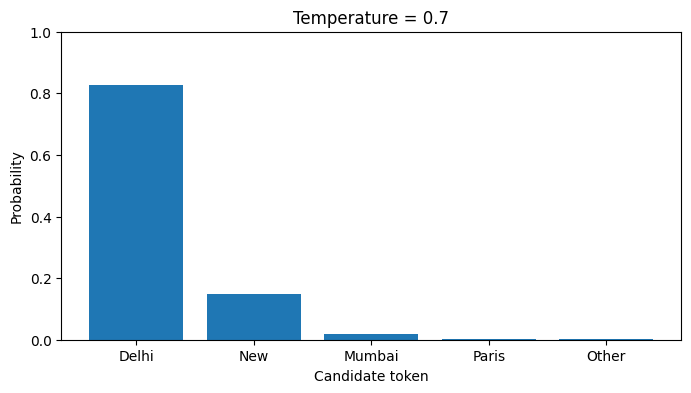

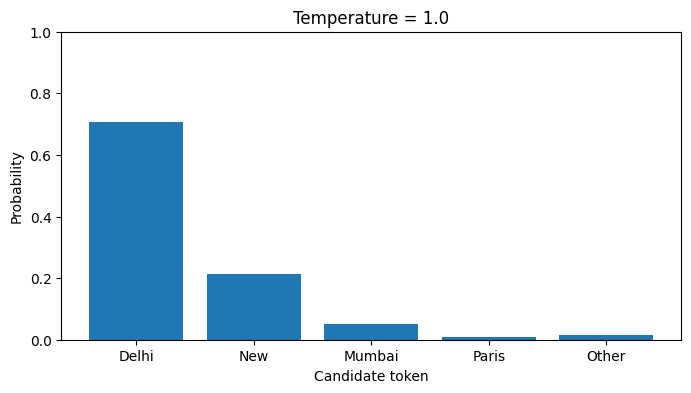

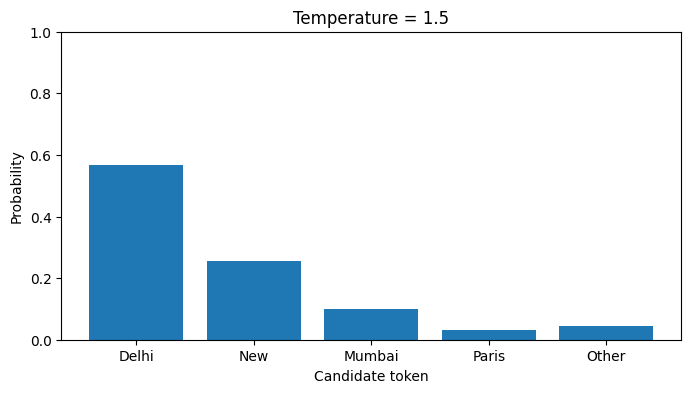

In [8]:
for temp in temps:
    probs = softmax(logits, temperature=temp)
    plt.figure(figsize=(8, 4))
    plt.bar(candidate_tokens, probs)
    plt.title(f"Temperature = {temp}")
    plt.xlabel("Candidate token")
    plt.ylabel("Probability")
    plt.ylim(0, 1)
    plt.show()

## 5.2 Sampling demo

Now we sample the next token many times and see how temperature changes outputs.

In [9]:
def sample_token(tokens, probs):
    return random.choices(tokens, weights=probs, k=1)[0]

for temp in [0.2, 0.7, 1.0, 1.5]:
    probs = softmax(logits, temperature=temp)
    samples = [sample_token(candidate_tokens, probs) for _ in range(30)]
    print(f"Temperature {temp}:")
    print(samples)
    print("Counts:", Counter(samples))
    print("-" * 70)

Temperature 0.2:
['Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi']
Counts: Counter({'Delhi': 30})
----------------------------------------------------------------------
Temperature 0.7:
['Delhi', 'Delhi', 'Delhi', 'New', 'Delhi', 'Delhi', 'New', 'Delhi', 'New', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'New', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi']
Counts: Counter({'Delhi': 26, 'New': 4})
----------------------------------------------------------------------
Temperature 1.0:
['Other', 'Delhi', 'Delhi', 'Delhi', 'New', 'New', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Mumbai', 'New', 'Delhi', 'Delhi', 'Delhi', 'New', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 'Delhi', 

## Temperature examples

Use low temperature for:

- SQL generation
- Data engineering code
- Production answers
- Legal/financial/medical summarization
- Factual Q&A

Use higher temperature for:

- Brainstorming
- Creative writing
- Ad copy
- Story generation
- Multiple idea generation

For interview and production coding, usually keep temperature low: **0 to 0.3**.

# 6. Embeddings

An **embedding** is a vector representation of text.

A vector is just a list of numbers.

Example:

```text
"king"  → [0.21, -0.10, 0.88, ...]
"queen" → [0.24, -0.08, 0.84, ...]
"banana"→ [-0.60, 0.70, 0.11, ...]
```

Texts with similar meaning usually have vectors closer together.

Embeddings are useful for:

- Semantic search
- RAG
- Clustering documents
- Recommendation systems
- Duplicate detection
- Classification features

## 6.1 Simple 2D embedding intuition

Real embeddings may have hundreds or thousands of dimensions.

For teaching, we use 2D vectors so students can visualize them.

Imagine two dimensions:

```text
x-axis: technology meaning
y-axis: food meaning
```

Words related to technology should be near each other.
Words related to food should be near each other.

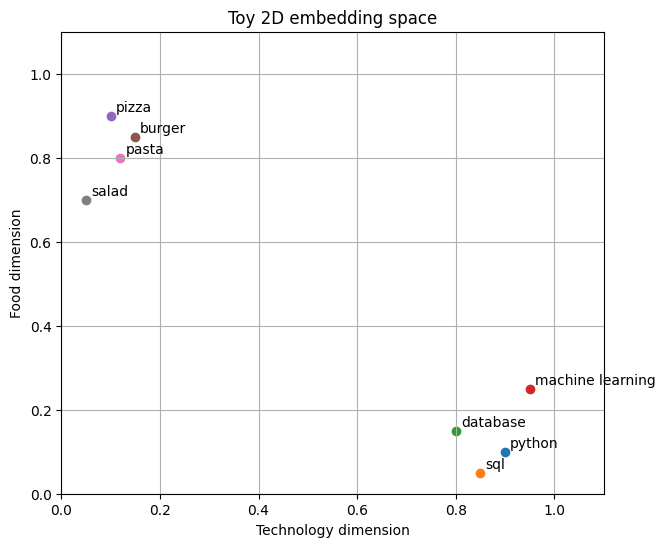

In [10]:
toy_embeddings = {
    "python": np.array([0.90, 0.10]),
    "sql": np.array([0.85, 0.05]),
    "database": np.array([0.80, 0.15]),
    "machine learning": np.array([0.95, 0.25]),
    "pizza": np.array([0.10, 0.90]),
    "burger": np.array([0.15, 0.85]),
    "pasta": np.array([0.12, 0.80]),
    "salad": np.array([0.05, 0.70]),
}

plt.figure(figsize=(7, 6))
for word, vec in toy_embeddings.items():
    plt.scatter(vec[0], vec[1])
    plt.text(vec[0] + 0.01, vec[1] + 0.01, word)

plt.title("Toy 2D embedding space")
plt.xlabel("Technology dimension")
plt.ylabel("Food dimension")
plt.xlim(0, 1.1)
plt.ylim(0, 1.1)
plt.grid(True)
plt.show()

# 7. Embedding geometry

Embeddings create a geometric space where meaning becomes distance/direction.

Important geometric ideas:

1. Similar texts are close.
2. Different texts are far.
3. Direction can represent meaning.
4. Search becomes nearest-neighbor lookup.

Example intuition:

```text
Vector("Python") is near Vector("SQL")
Vector("pizza") is near Vector("burger")
Vector("Python") is far from Vector("pizza")
```

## 7.1 Vector length and direction

A vector has:

- **Magnitude / length**: how long the vector is
- **Direction**: where the vector points

For semantic similarity, direction is often more important than length.

That is why cosine similarity is widely used.

In [11]:
def vector_norm(v):
    return np.linalg.norm(v)

for word in ["python", "sql", "pizza"]:
    v = toy_embeddings[word]
    print(word, "vector =", v, "length =", round(vector_norm(v), 3))

python vector = [0.9 0.1] length = 0.906
sql vector = [0.85 0.05] length = 0.851
pizza vector = [0.1 0.9] length = 0.906


# 8. Dot product

Dot product between two vectors:

```text
dot(a, b) = a1*b1 + a2*b2 + ... + an*bn
```

The dot product becomes large when:

1. Vectors point in a similar direction
2. Vectors have large magnitude

So dot product mixes **direction similarity** and **vector length**.

In [12]:
def dot_product(a, b):
    return float(np.dot(a, b))

pairs = [
    ("python", "sql"),
    ("python", "database"),
    ("python", "pizza"),
    ("pizza", "burger"),
]

for a, b in pairs:
    print(f"dot({a}, {b}) = {dot_product(toy_embeddings[a], toy_embeddings[b]):.3f}")

dot(python, sql) = 0.770
dot(python, database) = 0.735
dot(python, pizza) = 0.180
dot(pizza, burger) = 0.780


# 9. Cosine similarity

Cosine similarity measures the angle between two vectors.

```text
cosine_similarity(a, b) = dot(a, b) / (length(a) * length(b))
```

Range:

| Value | Meaning |
|---:|---|
| 1 | Same direction / very similar |
| 0 | Unrelated / perpendicular |
| -1 | Opposite direction |

Cosine focuses on direction, not magnitude.

In [13]:
def cosine_similarity(a, b):
    a = np.array(a, dtype=float)
    b = np.array(b, dtype=float)
    denominator = np.linalg.norm(a) * np.linalg.norm(b)
    if denominator == 0:
        return 0.0
    return float(np.dot(a, b) / denominator)

for a, b in pairs:
    print(f"cosine({a}, {b}) = {cosine_similarity(toy_embeddings[a], toy_embeddings[b]):.3f}")

cosine(python, sql) = 0.999
cosine(python, database) = 0.997
cosine(python, pizza) = 0.220
cosine(pizza, burger) = 0.998


## 9.1 Dot product vs cosine similarity

Dot product can be affected by vector length.
Cosine similarity mainly checks direction.

Let us compare two vectors pointing in the same direction but with different lengths.

In [14]:
a = np.array([1, 1])
b = np.array([10, 10])
c = np.array([1, 0])

print("a:", a)
print("b:", b)
print("c:", c)
print()
print("dot(a, b):", dot_product(a, b))
print("cosine(a, b):", cosine_similarity(a, b))
print()
print("dot(a, c):", dot_product(a, c))
print("cosine(a, c):", cosine_similarity(a, c))

a: [1 1]
b: [10 10]
c: [1 0]

dot(a, b): 20.0
cosine(a, b): 0.9999999999999998

dot(a, c): 1.0
cosine(a, c): 0.7071067811865475


*italicised text*##  

`a` and `b` point in the same direction, so cosine similarity is `1.0`.

But dot product is large because `b` has a bigger magnitude.

This is why many embedding search systems normalize vectors before using dot product.

When vectors are normalized to length 1:

```text
dot product = cosine similarity
```

In [ ]:
def normalize(v):
    norm = np.linalg.norm(v)
    if norm == 0:
        return v
    return v / norm

a_norm = normalize(a)
b_norm = normalize(b)

print("Normalized a:", a_norm)
print("Normalized b:", b_norm)
print("Dot after normalization:", dot_product(a_norm, b_norm))
print("Cosine after normalization:", cosine_similarity(a_norm, b_norm))

# 10. Similarity search demo

Now we build a tiny semantic search example.

Given a query vector, find the most similar documents.

This is the basic idea behind vector databases and RAG.

In [15]:
documents = {
    "doc_1": "Python is used for data engineering and automation.",
    "doc_2": "SQL is used to query databases.",
    "doc_3": "Pizza and burger are popular food items.",
    "doc_4": "Machine learning models learn patterns from data.",
    "doc_5": "A healthy salad contains vegetables.",
}

# Toy document embeddings, manually created for teaching
# x = tech meaning, y = food meaning
doc_embeddings = {
    "doc_1": np.array([0.92, 0.12]),
    "doc_2": np.array([0.86, 0.08]),
    "doc_3": np.array([0.12, 0.92]),
    "doc_4": np.array([0.95, 0.20]),
    "doc_5": np.array([0.08, 0.75]),
}

query = "How do I query data from a database?"
query_embedding = np.array([0.88, 0.10])

scores = []
for doc_id, doc_vec in doc_embeddings.items():
    scores.append({
        "doc_id": doc_id,
        "text": documents[doc_id],
        "cosine_similarity": cosine_similarity(query_embedding, doc_vec),
        "dot_product": dot_product(query_embedding, doc_vec),
    })

results = pd.DataFrame(scores).sort_values("cosine_similarity", ascending=False)
results

,doc_id,text,cosine_similarity,dot_product
0,doc_1,Python is used for data engineering and automa...,0.999863,0.8216
1,doc_2,SQL is used to query databases.,0.999792,0.7648
3,doc_4,Machine learning models learn patterns from data.,0.995553,0.8560
2,doc_3,Pizza and burger are popular food items.,0.240473,0.1976
4,doc_5,A healthy salad contains vegetables.,0.217660,0.1454


## 10.1 Visualizing query and document vectors

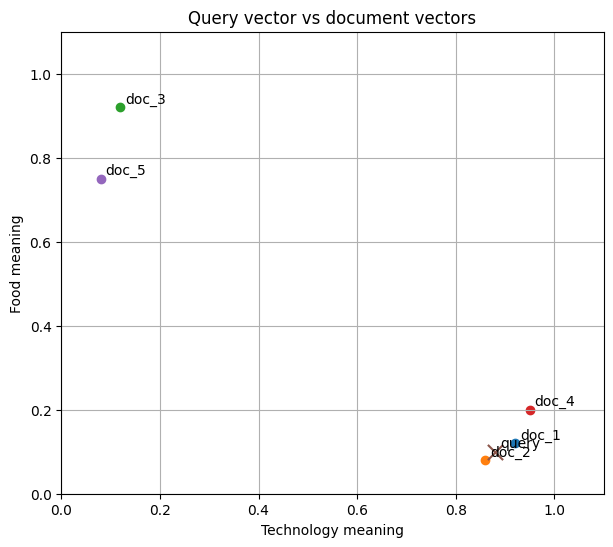

In [16]:
plt.figure(figsize=(7, 6))

for doc_id, vec in doc_embeddings.items():
    plt.scatter(vec[0], vec[1])
    plt.text(vec[0] + 0.01, vec[1] + 0.01, doc_id)

plt.scatter(query_embedding[0], query_embedding[1], marker="x", s=120)
plt.text(query_embedding[0] + 0.01, query_embedding[1] + 0.01, "query")

plt.title("Query vector vs document vectors")
plt.xlabel("Technology meaning")
plt.ylabel("Food meaning")
plt.xlim(0, 1.1)
plt.ylim(0, 1.1)
plt.grid(True)
plt.show()

# 11. Mini RAG intuition

RAG means **Retrieval-Augmented Generation**.

Basic flow:

```text
User question
   ↓
Create query embedding
   ↓
Search similar document embeddings
   ↓
Retrieve top-k documents
   ↓
Put retrieved docs into prompt/context
   ↓
LLM answers using retrieved context
```

Embeddings help find relevant information.
The LLM uses the retrieved text to answer.

Important distinction:

| Component | Job |
|---|---|
| Embedding model | Converts text into vectors |
| Vector database | Stores and searches vectors |
| LLM | Generates final natural-language answer |

# 12. Common beginner confusion

## Token vs embedding

| Concept | Meaning |
|---|---|
| Token | A piece of text |
| Token ID | Numeric ID for token |
| Embedding | Vector representation of token/text |

## Context window vs memory

| Concept | Meaning |
|---|---|
| Context window | What model can currently see |
| Memory | Stored user/project information that may be brought back later |
| RAG | External retrieval system to bring documents into context |

## Temperature vs accuracy

Temperature controls randomness, not knowledge.
A high temperature can make the model more creative but also more likely to produce unstable answers.


You can explain like this:

> An LLM is like a very advanced autocomplete system. It reads the input as tokens, converts those tokens into numbers, processes them using a transformer network, and predicts the next token. It repeats this process again and again to generate the answer.

For embeddings:

> Embeddings are like GPS coordinates for meaning. If two sentences have similar meaning, their coordinates are close. If their meaning is different, their coordinates are far.

For cosine similarity:

> Cosine similarity checks whether two meaning-vectors are pointing in the same direction. Same direction means similar meaning.

For context window:

> Context window is the model's working memory for the current answer. If something is not inside the context, the model may not use it.

For temperature:

> Temperature is the creativity knob. Low temperature gives safer predictable answers. High temperature gives more variety.

# 14. Student exercises

## Exercise 1: Tokenization

Tokenize the following sentence using `simple_tokenize`:

```text
LLMs are powerful, but prompts must be clear!
```

Questions:

1. How many tokens are there?
2. Is punctuation counted as a token?
3. Is this tokenizer same as a real LLM tokenizer?

In [17]:
# Exercise 1 solution area
sentence = "LLMs are powerful, but prompts must be clear!"
tokens = simple_tokenize(sentence)
print(tokens)
print("Token count:", len(tokens))

['LLMs', 'are', 'powerful', ',', 'but', 'prompts', 'must', 'be', 'clear', '!']
Token count: 10


## Exercise 2: Context window

Change `window_size` to 5, 10, and 20.

Observe which tokens remain visible.

In [18]:
# Exercise 2 solution area
window_size = 10
visible = apply_context_window(simple_tokenize(long_prompt), window_size)
print(visible)

['tokens', ',', 'context', 'window', ',', 'embeddings', ',', 'and', 'similarity', '.']


## Exercise 3: Temperature

Try temperature values:

```text
0.1, 0.5, 1.0, 2.0
```

Question:

Which one gives the most random output?

In [19]:
# Exercise 3 solution area
for temp in [0.1, 0.5, 1.0, 2.0]:
    probs = softmax(logits, temperature=temp)
    print("Temperature:", temp)
    print(dict(zip(candidate_tokens, np.round(probs, 3))))
    print()

Temperature: 0.1
{'Delhi': np.float64(1.0), 'New': np.float64(0.0), 'Mumbai': np.float64(0.0), 'Paris': np.float64(0.0), 'Other': np.float64(0.0)}

Temperature: 0.5
{'Delhi': np.float64(0.912), 'New': np.float64(0.083), 'Mumbai': np.float64(0.005), 'Paris': np.float64(0.0), 'Other': np.float64(0.0)}

Temperature: 1.0
{'Delhi': np.float64(0.709), 'New': np.float64(0.213), 'Mumbai': np.float64(0.053), 'Paris': np.float64(0.01), 'Other': np.float64(0.016)}

Temperature: 2.0
{'Delhi': np.float64(0.479), 'New': np.float64(0.263), 'Mumbai': np.float64(0.131), 'Paris': np.float64(0.056), 'Other': np.float64(0.072)}



## Exercise 4: Similarity

Add a new document:

```text
"Airflow schedules data pipelines."
```

Give it a toy embedding near the technology cluster and rerun similarity search.

In [20]:
# Exercise 4 solution area
new_doc_id = "doc_6"
documents[new_doc_id] = "Airflow schedules data pipelines."
doc_embeddings[new_doc_id] = np.array([0.90, 0.06])

scores = []
for doc_id, doc_vec in doc_embeddings.items():
    scores.append({
        "doc_id": doc_id,
        "text": documents[doc_id],
        "cosine_similarity": cosine_similarity(query_embedding, doc_vec),
    })

pd.DataFrame(scores).sort_values("cosine_similarity", ascending=False)

,doc_id,text,cosine_similarity
0,doc_1,Python is used for data engineering and automa...,0.999863
1,doc_2,SQL is used to query databases.,0.999792
5,doc_6,Airflow schedules data pipelines.,0.998915
3,doc_4,Machine learning models learn patterns from data.,0.995553
2,doc_3,Pizza and burger are popular food items.,0.240473
4,doc_5,A healthy salad contains vegetables.,0.217660


# 15. Interview-style questions for students

1. What is a token?
2. Why does token count matter?
3. What is context window?
4. What happens if important information is outside context window?
5. What is temperature?
6. Why should coding tasks use low temperature?
7. What is an embedding?
8. Why are embeddings useful in RAG?
9. Difference between dot product and cosine similarity?
10. Why does vector normalization make dot product similar to cosine similarity?

# 16. Day 1 recap

Today we learned:

- LLMs generate text by predicting the next token.
- Text is first broken into tokens.
- Tokens become token IDs.
- The model uses embeddings and transformer layers internally.
- Context window is the maximum visible token space.
- Temperature controls randomness during output generation.
- Embeddings convert meaning into vectors.
- Cosine similarity compares vector direction.
- Dot product combines direction and magnitude.
- Similarity search is the foundation of RAG.

## One-line summary

> LLMs work by converting text into numbers, processing those numbers, and generating the next token; embeddings help represent meaning as vectors for search and retrieval.

# 17. Homework

Ask students to write answers in their own words:

1. Explain LLM internals using a food-ordering analogy.
2. Give 3 examples where low temperature is better.
3. Give 3 examples where high temperature is better.
4. Explain why embeddings are useful for document search.
5. Create 5 toy documents and manually assign 2D embeddings.
6. Compute cosine similarity between a query and those documents.